sigmoid function dependend on $Mg^{2+}$ concentration (Gaussian)

In [1]:
#%pip install matplotlib

In [2]:
#import sys
#print(sys.executable)

In [21]:
import math
import matplotlib.pyplot as plt

In [4]:

conc = [20, 30, 40, 50, 60, 70, 80] # MgCl2 concentration, mM
yield_mass = [250, 370, 370, 360, 300, 260, 170] # 6H x 10H x 128B cuboid yield, ng
yield_perc = [2.5, 3.7, 3.7, 3.6, 3.0, 2.6, 1.7] # 6H x 10H x 128B cuboid yield, %

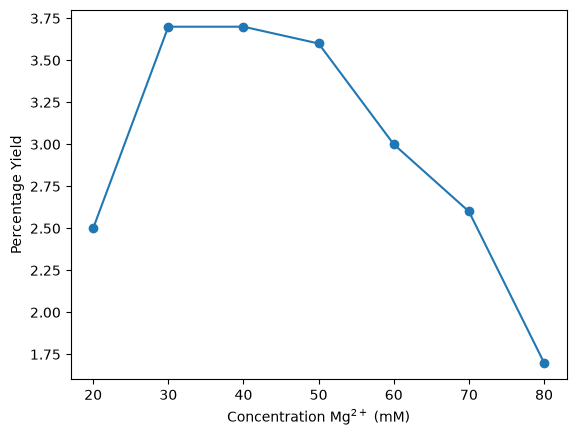

In [5]:
plt.plot(conc, yield_perc, "o-", label = 'Measured Data')
plt.xlabel("Concentration Mg$^{2+}$ (mM)")
plt.ylabel("Percentage Yield")
plt.show()



y=A*exp(-((x-mu)^2)/2sigma^2)​

In [9]:
#Gaussian predicted model
def gaussian_pred(x, A, mu, sigma):
    return A * math.exp(-((x - mu)**2) / (2 * sigma **2))
    

Initial_A_fit = 3.7  #peak of plot
Initial_mu_fit = 35.0 #plot peaks at ~30-40 
Initial_sigma_fit = 15.0 #35 - 15 = 20 mM, 35 + 15 = 50, covers majority of yield, since it starts to drop off above and below that


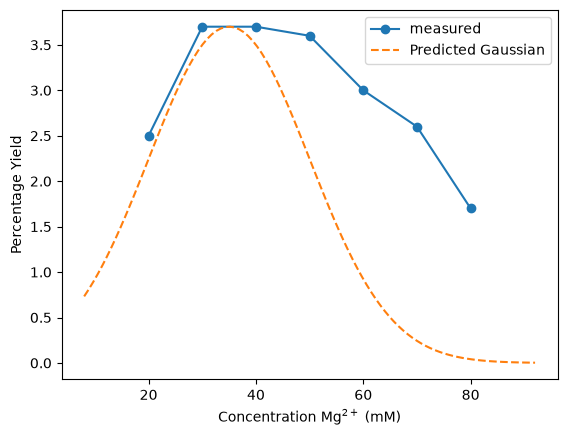

In [10]:
#Plot Gaussian prediced model 

# step 1: create a range
min_conc = min(conc)
max_conc = max(conc)
num_points = 100 #num of points in graph
#
# (max - min = total range 
# * 0.2 = 20% of range,) = buffer
#min - buffer extends range to the left of min conc, to allow visualsiaton of initial rise even outside data
#max + buffer extends range to the right of mix conc, to allow visualsiaton of initial rise even outside data
plot_start = min_conc - (max_conc - min_conc) * 0.2 
plot_end = max_conc + (max_conc - min_conc) * 0.2
conc_range = []
step_size = (plot_end - plot_start) / (num_points - 1) 
for i in range(num_points):
    conc_range.append(plot_start + i * step_size) #creates list of values


# step 2: calculate fitted yield percentages
predicted_yield_perc = [gaussian_pred(c, Initial_A_fit, Initial_mu_fit, Initial_sigma_fit) for c in conc_range]

# step 3: plot the lines
plt.plot(conc, yield_perc, "o-", label="measured")
plt.plot(conc_range, predicted_yield_perc, '--', label = 'Predicted Gaussian')
plt.xlabel("Concentration Mg$^{2+}$ (mM)")
plt.ylabel("Percentage Yield")
plt.legend()
plt.show()




In [11]:
#Gaussian fitted function 

sigma_yield = 0.2 # assumed uncertainty for yield

def gaussian_pdf(x, mu, sigma): #calculates the probability density  at x for mean and sigma
    return math.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) / (sigma * math.sqrt(2 * math.pi))


def nll(A, mu, sigma):
    total = 0.0
    for i in range(len(conc)):
      concs = conc[i]
      yield_percs = yield_perc[i]

      yield_percs_predicted = gaussian_pred(concs, A, mu, sigma)
      
    
      total =  total - math.log(gaussian_pdf(yield_percs, yield_percs_predicted, sigma_yield))
    return total




In [66]:
#Perform grid search
A_range = [i * 0.1 for i in range(20,50)] #range covering the 3.7 value from initial_A_fit
mu_range = [i * 0.5 for i in range(40,90)] #range covering the 35.0 value from initial_mu_fit (40 * 0.5 = 20 etc)
sigma_range = [i * 0.5 for i in range(10,80)] #range covering 5 to 39.5 
grid = [
    (A, mu, sigma)
    for A in A_range 
    for mu in mu_range
    for sigma in sigma_range
]

scores = [0.0] * len(grid)
for i in range(len(grid)):
    A, mu, sigma = grid[i]
    scores[i] = nll(A, mu, sigma)

position = scores.index(min(scores))

print("Original:")
print(grid[position])
print(scores[position])

best_A, best_mu, best_sigma = grid[position]
best_nll = scores[position]



Original:
(3.8000000000000003, 43.5, 28.5)
-2.1613013268379357


In [67]:
#fit graph using best values
fitted_yield_perc = [gaussian_pred(c, best_A, best_mu, best_sigma) for c in conc_range]

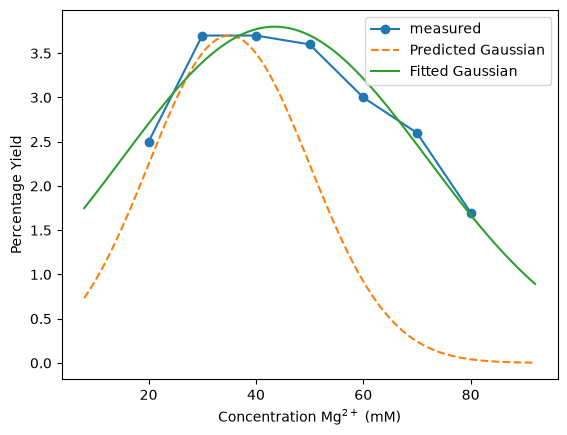

In [14]:
#plot the lines
plt.plot(conc, yield_perc, "o-", label="measured")
plt.plot(conc_range, predicted_yield_perc, '--', label = 'Predicted Gaussian')
plt.plot(conc_range, fitted_yield_perc, '-', label = 'Fitted Gaussian')
plt.xlabel("Concentration Mg$^{2+}$ (mM)")
plt.ylabel("Percentage Yield")
plt.legend(loc = "upper right")
plt.show()

In [17]:
import numpy as np


In [ ]:
#%pip install scipy

In [68]:
import scipy as sci
from scipy.stats import bootstrap
seed = np.random.default_rng(8)

In [ ]:
#Define mu_hat (via NLL)
def mu_hat(conc_sim, yield_p_sim):
    scores = [0.0] *len(grid)
    for i in range(len(grid)):
        A, mu, sigma = grid[i]
        total = 0.0
        for j in range(len(conc_sim)):
            conc_sims = conc_sim[j]
            yield_p_sims = yield_p_sim[j]
            predicted_yield_at_conc = gaussian_pred(conc_sims, A, mu, sigma)

            total = total - math.log(gaussian_pdf(yield_p_sims, predicted_yield_at_conc,sigma_yield))
        scores[i] = total

    position = scores.index(min(scores))
    best_A, best_mu, best_sigma = grid [position] 
    return best_mu



In [70]:
print(mu_hat(conc, yield_perc))

43.5


In [71]:
print(nll(3.8, 43.5, 28.5))

-2.16130132683794


In [79]:
print(dist.bootstrap_distribution)

[44.5 44.5 44.5 43.5 38.5 38.  43.  44.5 44.  39.  43.5 38.  39.5 44.5
 38.5 43.  41.5 37.5 44.  43.  38.5 42.  43.  35.  40.5 40.5 42.5 42.5
 44.5 43.5 35.5 38.5 37.5 37.5 37.5 44.5 37.5 37.5 42.  44.5 40.  43.5
 39.5 44.  44.5 38.  44.5 44.5 42.  39.  38.5 44.  42.  44.5 44.  40.
 42.  42.5 44.5 44.  37.5 42.5 37.5 44.5 38.5 43.  44.5 43.  39.  44.5
 42.  43.5 43.  40.5 44.5 44.  38.  43.  44.5 37.  43.5 43.5 44.5 37.
 39.  38.5 38.5 36.5 44.5 39.  44.5 44.5 44.5 43.5 41.  44.5 39.  37.5
 43.5 43.  44.5 44.5 44.5 38.  44.5 38.5 44.5 39.  43.5 38.  44.5 44.5
 37.5 42.  36.  44.5 44.5 44.  39.  44.  43.5 44.  41.5 44.  44.5 41.
 40.  44.5 39.5 38.5 44.5 38.  38.5 35.5 42.5 41.5 37.5 38.5 44.  44.5
 43.  43.  44.5 35.  41.5 44.5 42.  38.  44.5 36.5 38.5 38.5 38.5 42.5
 44.5 43.  42.5 40.5 43.5 37.5 43.5 44.5 31.  44.5 41.  38.5 38.  40.5
 39.  44.5 44.5 44.  44.5 37.  37.  41.5 44.5 44.5 44.  44.  37.  44.5
 44.  37.5 44.5 40.5 37.5 44.5 44.5 37.5 44.5 43.5 44.  41.5 36.5 39.5
 43.  41.

In [74]:
print(best_A)
print(best_mu)
print(best_sigma)
print(best_nll)
print(mu_hat(conc, yield_perc))

3.8000000000000003
43.5
28.5
-2.1613013268379357
43.5


In [ ]:
#Perform Bootstrap
data = (conc, yield_perc)


dist = bootstrap(data, mu_hat, n_resamples= 350, confidence_level= 0.9, paired = True, rng = seed, vectorized = False)



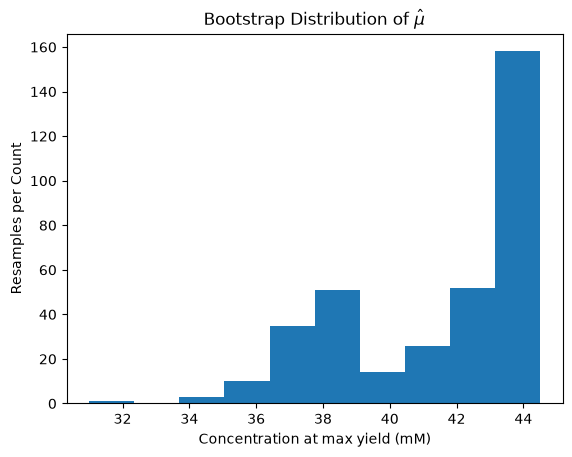

In [78]:
fig, ax = plt.subplots()
ax.hist(dist.bootstrap_distribution, bins=10)
ax.set_title('Bootstrap Distribution of $\\hat{\\mu}$')
ax.set_xlabel('Concentration at max yield (mM)')
ax.set_ylabel('Resamples per Count')
plt.show()